This notebook plots Fig. 3D-F and S4E-H plots.

The notebook uses the following inputs from "7. Multiome 3 - input preparation for Fig. 3D-F, S4E-H":
1. Downsampled control cholinergic neuron ArchR project (proj_cholinergic_ctl_downsamp)
2. Downsampled control ArchR projects for each cholinergic type (proj_alpha_ctl_downsamp, proj_gamma_ctl_downsamp, proj_gammaStar_ctl_downsamp, proj_Gad1CholInter_ctl_downsamp, proj_Pitx2CholInter_ctl_downsamp, proj_visc_ctl_downsamp)
3. Differentially accessible peaks with disease (control vs. mid/end) for MN subtypes (marker_lists_mn_downsamp.rds)


## Setup

In [1]:
# Paths
SOD1_RENV_MULTIOME <- "/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-Multiome/"
SOD1_MULTIOME_DIR  <- "/oak/stanford/groups/agitler/Shared/SOD1_Paper/Multiome"

renv::load(SOD1_RENV_MULTIOME)
Sys.setenv(SOD1_MULTIOME_DIR = SOD1_MULTIOME_DIR)

# Packages
suppressPackageStartupMessages({
  pkgs <- c(
    "ArchR", "future", "dplyr", "BSgenome.Mmusculus.UCSC.mm10",
    "pheatmap", "ggpubr", "ggrepel", "ggbreak", "cowplot",
    "Seurat", "forcats"
  )
  invisible(lapply(pkgs, library, character.only = TRUE))
})

# ArchR / future settings
addArchRGenome("mm10")
addArchRThreads(threads = 16)

plan(strategy = "multicore", workers = 16)
options(future.globals.maxSize = 41953040000)

# ArchR project paths
project_path <- function(name) file.path(SOD1_MULTIOME_DIR, name)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

## Control cholinergic neuron plots

In [2]:
# Load proj_cholinergic_ctl_downsamp ArchR project
proj_cholinergic_ctl_downsamp <- loadArchRProject(project_path("proj_cholinergic_ctl_downsamp"))

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [3]:
orig_lvls <- levels(factor(proj_cholinergic_ctl_downsamp$cholinergic_type))

proj_cholinergic_ctl_downsamp$cholinergic_type <- recode(
  as.character(proj_cholinergic_ctl_downsamp$cholinergic_type),
  "Gad1+ Cholinergic Interneurons"  = "Gad1+ CI",
  "Pitx2+ Cholinergic Interneurons" = "Pitx2+ CI",
  "Alpha MNs"    = "Alpha",
  "Gamma MNs"    = "Gamma",
  "Gamma* MNs"   = "Gamma*",
  "Visceral MNs" = "Visceral"
)

new_lvls <- recode(
  orig_lvls,
  "Gad1+ Cholinergic Interneurons"  = "Gad1+ CI",
  "Pitx2+ Cholinergic Interneurons" = "Pitx2+ CI",
  "Alpha MNs"    = "Alpha",
  "Gamma MNs"    = "Gamma",
  "Gamma* MNs"   = "Gamma*",
  "Visceral MNs" = "Visceral",
  .default = orig_lvls
)
proj_cholinergic_ctl_downsamp$cholinergic_type <-
  factor(proj_cholinergic_ctl_downsamp$cholinergic_type, levels = new_lvls)

proj_cholinergic_ctl_downsamp$cholinergic_type_chr <-
  as.character(proj_cholinergic_ctl_downsamp$cholinergic_type)

group_order_chr <- as.character(new_lvls)

### Fragment size distributions

ArchR logging to : ArchRLogs/ArchR-plotFragmentSizes-2c34455442c4-Date-2026-06-22_Time-00-09-55.log
If there is an issue, please report to github with logFile!

ArchR logging successful to : ArchRLogs/ArchR-plotFragmentSizes-2c34455442c4-Date-2026-06-22_Time-00-09-55.log



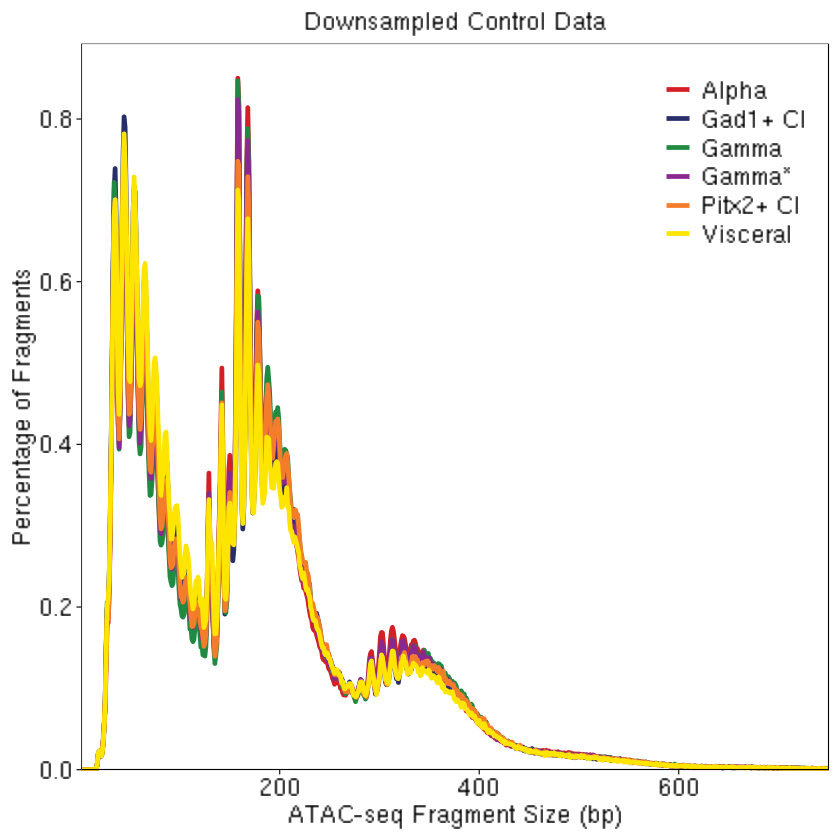

In [4]:
ctl_chol_fragment_sizes <- plotFragmentSizes(
  ArchRProj = proj_cholinergic_ctl_downsamp,
  groupBy   = "cholinergic_type"
) +
  ggtitle("Downsampled Control Data") +
  guides(color = guide_legend(title = NULL),
         fill  = guide_legend(title = NULL)) +
  theme(
    plot.title         = element_text(hjust = 0.5, size = 14),
    text               = element_text(size = 14),
    axis.title         = element_text(size = 14),
    axis.text          = element_text(size = 14),
    legend.text        = element_text(size = 14),
    legend.position    = c(0.98, 0.98),
    legend.justification = c("right", "top"),
    legend.background  = element_rect(fill = "white", color = NA),
    plot.margin        = margin(7, 7, 7, 7)
  )

ctl_chol_fragment_sizes

### Insertion profiles

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-2c342691c062-Date-2026-06-22_Time-00-10-43.log
If there is an issue, please report to github with logFile!

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-2c342691c062-Date-2026-06-22_Time-00-10-43.log



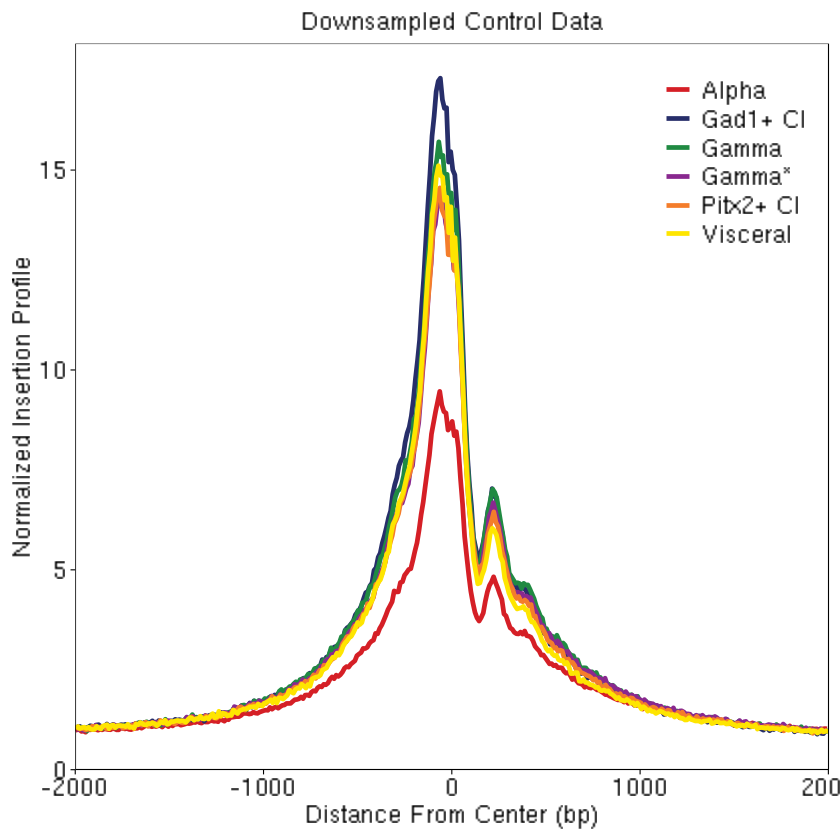

In [5]:
ctl_chol_insertion_profiles <- plotTSSEnrichment(
  ArchRProj = proj_cholinergic_ctl_downsamp,
  groupBy   = "cholinergic_type"
) +
  ggtitle("Downsampled Control Data") +
  guides(color = guide_legend(title = NULL),
         fill  = guide_legend(title = NULL)) +
  theme(
    plot.title          = element_text(hjust = 0.5, size = 14),
    text                = element_text(size = 14),
    axis.title          = element_text(size = 14),
    axis.text           = element_text(size = 14),
    legend.text         = element_text(size = 14),
    legend.position     = c(0.98, 0.98),
    legend.justification= c("right", "top"),
    legend.background   = element_rect(fill = "white", color = NA),
    plot.margin         = margin(7, 7, 7, 7)
  )

ctl_chol_insertion_profiles

### TSS enrichment

1 




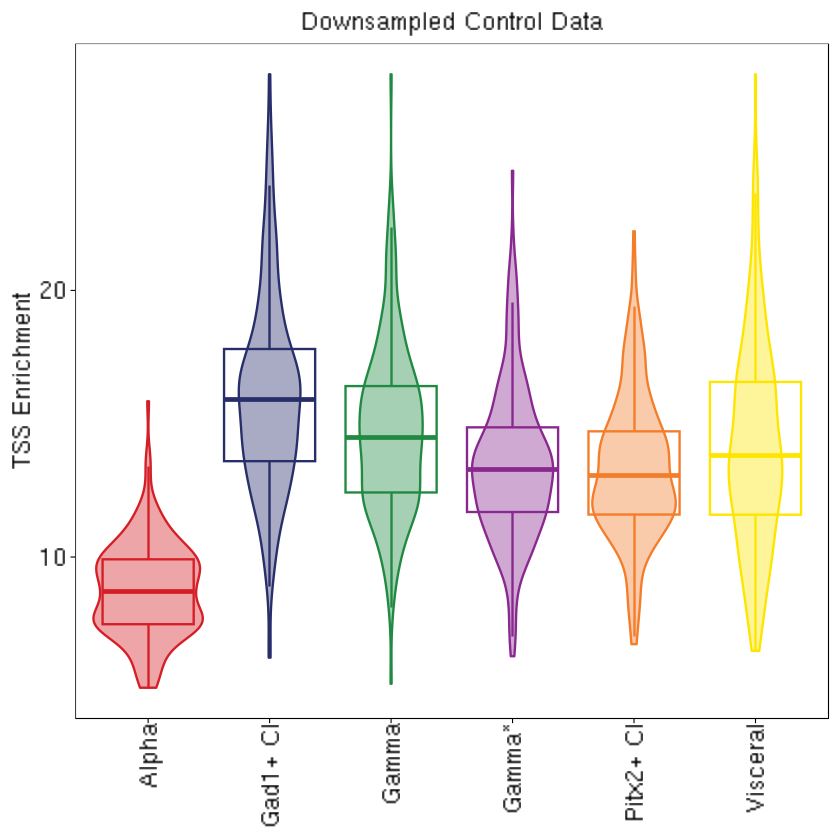

In [6]:
ctl_chol_tss_enrichment <- plotGroups(
  ArchRProj  = proj_cholinergic_ctl_downsamp,
  groupBy    = "cholinergic_type_chr",
  colorBy    = "cellColData",
  name       = "TSSEnrichment",
  plotAs     = "violin",
  alpha      = 0.4,
  baseSize   = 14,
  addBoxPlot = TRUE,
  groupOrder = group_order_chr
) +
  ggtitle("Downsampled Control Data") +
  labs(y = "TSS Enrichment", x = NULL) +
  theme(
    plot.title   = element_text(hjust = 0.5, size = 14),
    text         = element_text(size = 14),
    axis.title   = element_text(size = 14),
    axis.text    = element_text(size = 14),
    plot.margin  = margin(7, 7, 7, 7),
    legend.position = "none"
  )

ctl_chol_tss_enrichment

### FRIP distributions per cholinergic type

In [7]:
# Load ArchR projects
proj_alpha_ctl_downsamp <- loadArchRProject(project_path("proj_alpha_ctl_downsamp"))
proj_gamma_ctl_downsamp <- loadArchRProject(project_path("proj_gamma_ctl_downsamp"))
proj_gammaStar_ctl_downsamp <- loadArchRProject(project_path("proj_gammaStar_ctl_downsamp"))
proj_Gad1CholInter_ctl_downsamp <- loadArchRProject(project_path("proj_Gad1CholInter_ctl_downsamp"))
proj_Pitx2CholInter_ctl_downsamp <- loadArchRProject(project_path("proj_Pitx2CholInter_ctl_downsamp"))
proj_visc_ctl_downsamp <- loadArchRProject(project_path("proj_visc_ctl_downsamp"))

cholinergic_ctl_downsamp_list_wpeaks <- list(proj_alpha_ctl_downsamp, proj_gamma_ctl_downsamp, proj_gammaStar_ctl_downsamp,
                                 proj_Gad1CholInter_ctl_downsamp, proj_Pitx2CholInter_ctl_downsamp, proj_visc_ctl_downsamp)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

Will add FRIP_local for 1344 cells (out of 1344 in merged).

1 




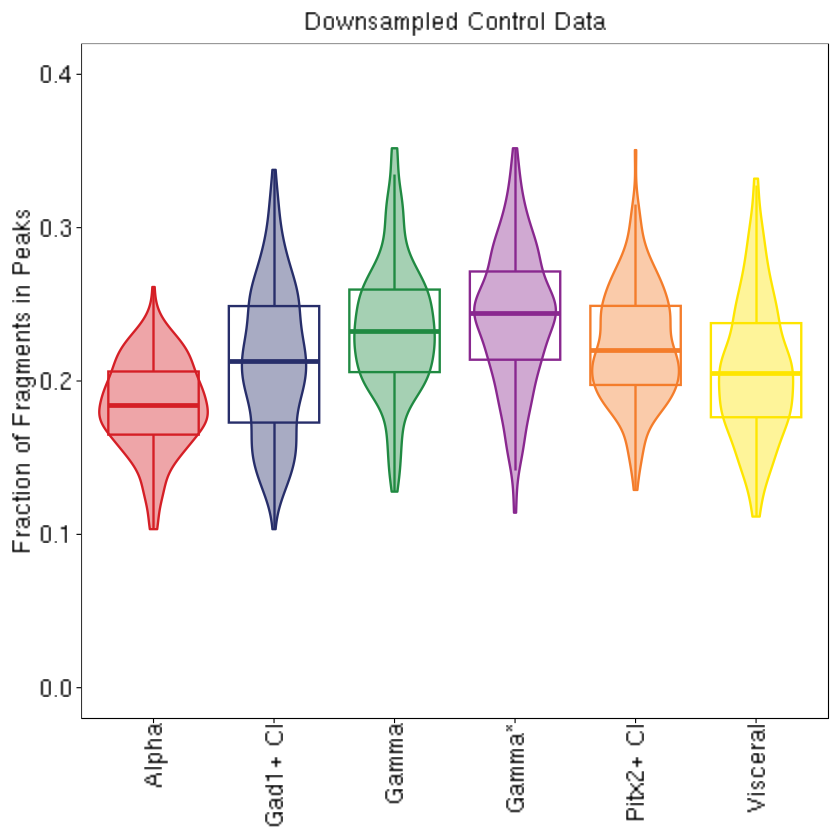

In [8]:
# Build a named numeric vector of FRIP from the individual projects
frip_vec <- unlist(lapply(cholinergic_ctl_downsamp_list_wpeaks, function(p) {
  cc <- getCellColData(p, select = "FRIP", drop = FALSE)
  if (is.null(cc) || ncol(cc) == 0) return(NULL)
  v <- cc[, 1]
  names(v) <- rownames(cc)  # cell names
  v
}), use.names = TRUE)

frip_vec <- frip_vec[is.finite(frip_vec)]

# Align to the merged project's cells
cells_merged <- getCellNames(proj_cholinergic_ctl_downsamp)
keep <- intersect(names(frip_vec), cells_merged)

message(sprintf("Will add FRIP_local for %d cells (out of %d in merged).",
                length(keep), length(cells_merged)))

# Add to merged project as FRIP_local 
proj_cholinergic_ctl_downsamp <- addCellColData(
  ArchRProj = proj_cholinergic_ctl_downsamp,
  data      = frip_vec[keep],
  name      = "FRIP_local",
  cells     = keep,
  force     = TRUE
)

# FRIP violin
ctl_chol_frip <- plotGroups(
  ArchRProj  = proj_cholinergic_ctl_downsamp,
  groupBy    = "cholinergic_type_chr",
  colorBy    = "cellColData",
  name       = "FRIP_local",
  plotAs     = "violin",
  alpha      = 0.4,
  baseSize   = 14,
  addBoxPlot = TRUE,
  groupOrder = group_order_chr
) +
  ggtitle("Downsampled Control Data") +
  labs(y = "Fraction of Fragments in Peaks", x = NULL) +
  ylim(0, 0.4) +
  theme(
    plot.title   = element_text(hjust = 0.5, size = 14),
    text         = element_text(size = 14),
    axis.title   = element_text(size = 14),
    axis.text    = element_text(size = 14),
    legend.position = "none",
    plot.margin  = margin(7, 7, 7, 7)
  )

ctl_chol_frip

### Fragment number distributions

1 




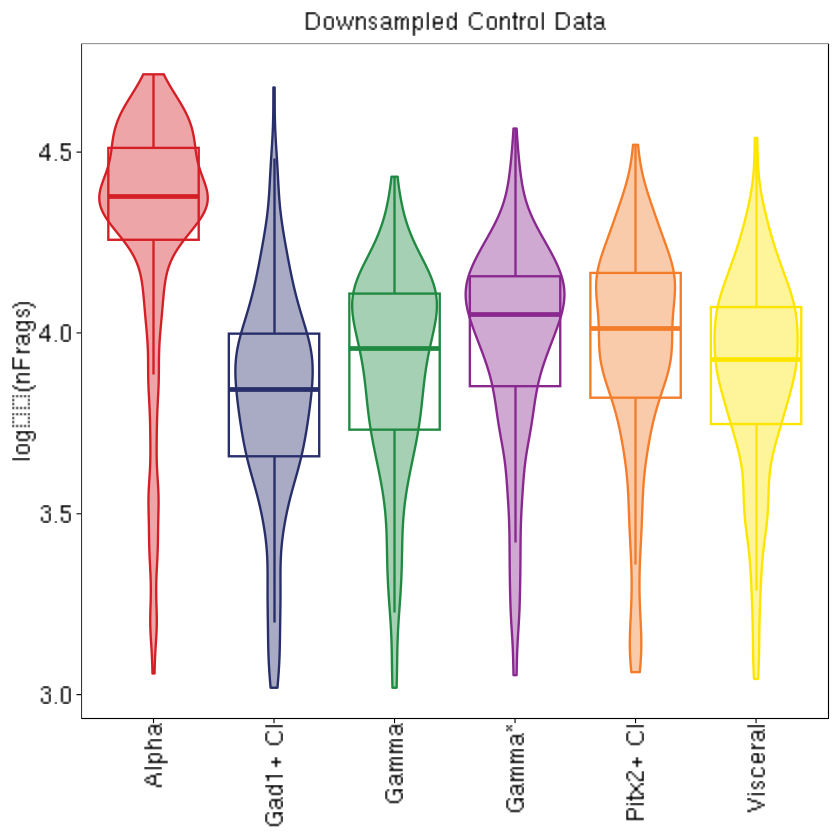

In [9]:
ctl_chol_fragments <- plotGroups(
  ArchRProj  = proj_cholinergic_ctl_downsamp,
  groupBy    = "cholinergic_type_chr",
  colorBy    = "cellColData",
  name       = "log10(nFrags)",
  plotAs     = "violin",
  alpha      = 0.4,
  baseSize   = 14,
  addBoxPlot = TRUE,
  groupOrder = group_order_chr
) +
  ggtitle("Downsampled Control Data") +
  labs(y = "log₁₀(nFrags)", x = NULL) +
  theme(
    plot.title   = element_text(hjust = 0.5, size = 14),
    text         = element_text(size = 14),
    axis.title   = element_text(size = 14),
    axis.text    = element_text(size = 14),
    plot.margin  = margin(7, 7, 7, 7),
    legend.position = "none"
  )

ctl_chol_fragments

### Number of peaks per cholinergic type

In [10]:
# Load ArchR projects
proj_alpha_ctl_downsamp <- loadArchRProject(project_path("proj_alpha_ctl_downsamp"))
proj_gamma_ctl_downsamp <- loadArchRProject(project_path("proj_gamma_ctl_downsamp"))
proj_gammaStar_ctl_downsamp <- loadArchRProject(project_path("proj_gammaStar_ctl_downsamp"))
proj_Gad1CholInter_ctl_downsamp <- loadArchRProject(project_path("proj_Gad1CholInter_ctl_downsamp"))
proj_Pitx2CholInter_ctl_downsamp <- loadArchRProject(project_path("proj_Pitx2CholInter_ctl_downsamp"))
proj_visc_ctl_downsamp <- loadArchRProject(project_path("proj_visc_ctl_downsamp"))

cholinergic_ctl_downsamp_list_wpeaks <- list(proj_alpha_ctl_downsamp, proj_gamma_ctl_downsamp, proj_gammaStar_ctl_downsamp,
                                 proj_Gad1CholInter_ctl_downsamp, proj_Pitx2CholInter_ctl_downsamp, proj_visc_ctl_downsamp)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

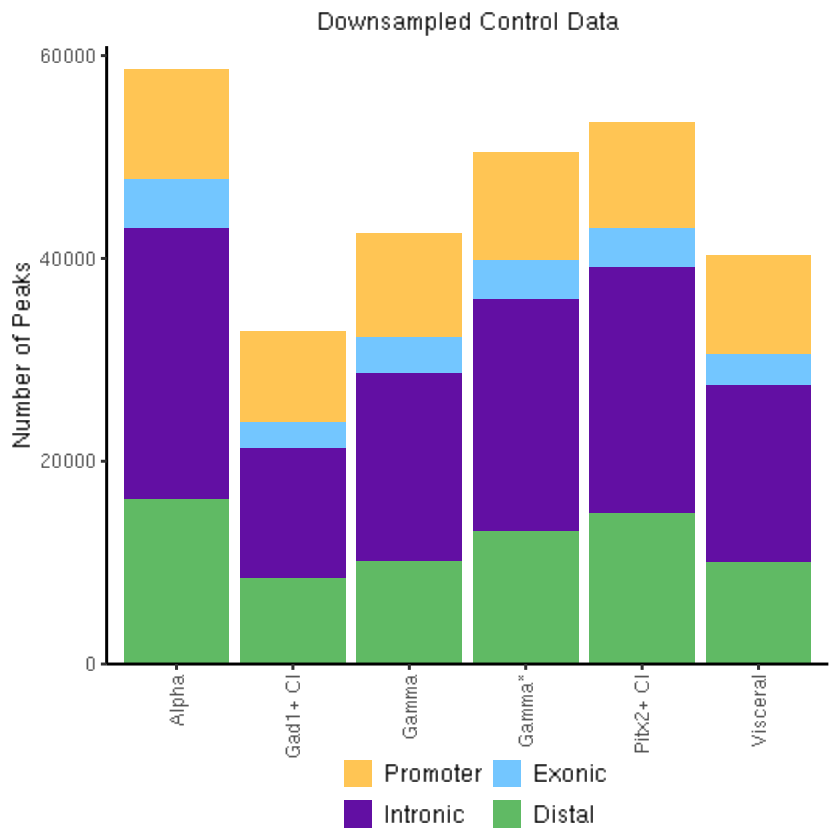

In [11]:
peak_counts_by_type <- function(proj_list) {
  ann_levels <- c("Promoter", "Exonic", "Intronic", "Distal")

  rows <- lapply(seq_along(proj_list), function(i) {
    proj   <- proj_list[[i]]
    peakGR <- getPeakSet(proj)

    pt <- dplyr::recode(mcols(peakGR)$peakType, Exon = "Exonic", Intron = "Intronic")
    pt <- factor(pt, levels = ann_levels)
    counts_df <- as.data.frame(table(pt))
    colnames(counts_df) <- c("Annotation", "n")
    counts_df$prop <- counts_df$n / sum(counts_df$n)

    chol_label <- tryCatch({
      u <- unique(as.character(getCellColData(proj, "cholinergic_type")[,1]))
      if (length(u) == 1) u else paste0("proj_", i)
    }, error = function(...) {
      nm <- tryCatch(ArchR::getProjectSummary(proj)$ProjectName, error = function(...) NA_character_)
      ifelse(is.na(nm), paste0("proj_", i), nm)
    })

    counts_df$cholinergic_type <- chol_label
    counts_df
  })

  bind_rows(rows) |>
    mutate(Annotation = factor(Annotation, levels = ann_levels))
}

peak_counts_df <- peak_counts_by_type(cholinergic_ctl_downsamp_list_wpeaks)

pal <- c("Distal"="#60BA64","Exonic"="#73C6FF","Intronic"="#620FA3","Promoter"="#FFC554")

ctl_chol_peaks <- ggplot(peak_counts_df, aes(x = cholinergic_type, y = n, fill = Annotation)) +
  geom_col() +
  scale_fill_manual(values = pal, drop = FALSE) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.04))) +
  scale_x_discrete(labels = function(l) dplyr::recode(l,
    "Alpha MNs"                       = "Alpha",
    "Gamma MNs"                       = "Gamma",
    "Gamma* MNs"                      = "Gamma*",
    "Visceral MNs"                    = "Visceral",
    "Gad1+ Cholinergic Interneurons"  = "Gad1+ CI",
    "Pitx2+ Cholinergic Interneurons" = "Pitx2+ CI",
    .default = l
  )) +
  labs(
    title = "Downsampled Control Data",
    x = NULL,
    y = "Number of Peaks",
    fill = NULL
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title    = element_text(hjust = 0.5, size = 14),
    axis.text.x   = element_text(angle = 90, hjust = 1, vjust = 0.5),
    legend.title  = element_blank(),
    legend.text   = element_text(size = 14),
    legend.position = "bottom",
    legend.box.spacing = unit(0, "pt"),
    legend.margin      = margin(0, 0, 0, 0),
    plot.margin        = margin(7, 7, 7, 7)
  ) +
  guides(fill = guide_legend(nrow = 2, byrow = TRUE))

ctl_chol_peaks

### Number of differentially accessible peaks with disease (control vs. mid/end) for MN subtypes

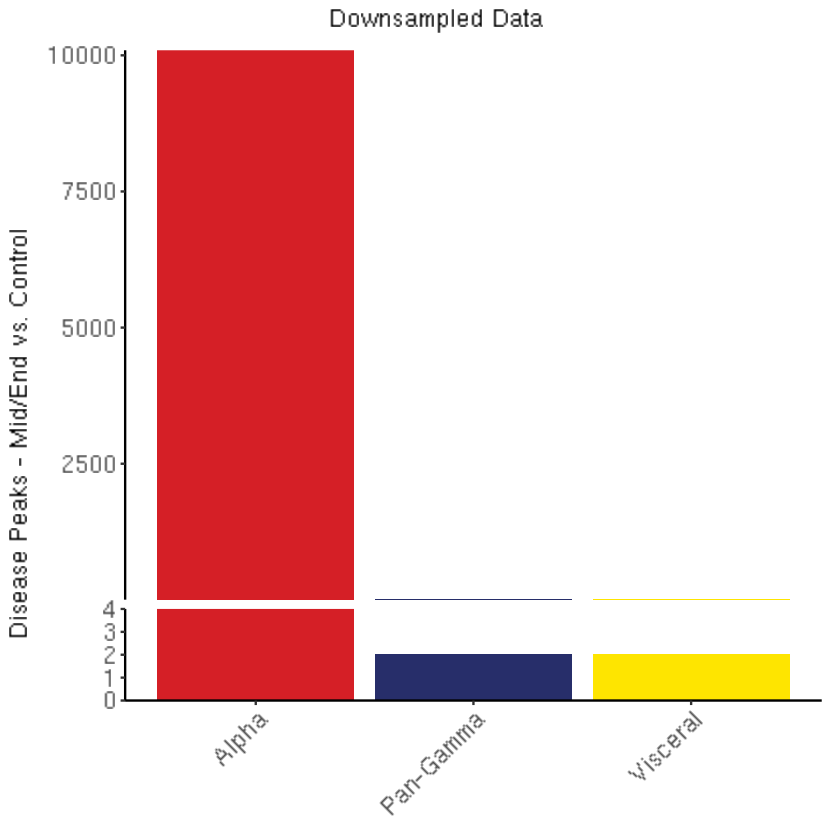

In [12]:
marker_lists_mn_downsamp <- readRDS(project_path("marker_lists_mn_downsamp.rds"))

alpha_disease_up <- sum(marker_lists_mn_downsamp[[1]][[1]]$FDR <= 0.1)
alpha_disease_down <- sum(marker_lists_mn_downsamp[[1]][[2]]$FDR <= 0.1)

panGamma_disease_up <- sum(marker_lists_mn_downsamp[[2]][[1]]$FDR <= 0.1)
panGamma_disease_down <- sum(marker_lists_mn_downsamp[[2]][[2]]$FDR <= 0.1)

visc_disease_up <- sum(marker_lists_mn_downsamp[[3]][[1]]$FDR <= 0.1)
visc_disease_down <- sum(marker_lists_mn_downsamp[[3]][[2]]$FDR <= 0.1)

mn_disease_up <- data.frame("Alpha" = alpha_disease_up, "Pan-Gamma" = panGamma_disease_up, "Visceral" = visc_disease_up)
mn_disease_down <- data.frame("Alpha" = alpha_disease_down, "Pan-Gamma" = panGamma_disease_down, "Visceral" = visc_disease_down)

alpha_disease <- alpha_disease_up + alpha_disease_down
panGamma_disease <- panGamma_disease_up + panGamma_disease_down
visc_disease <- visc_disease_up + visc_disease_down

disease_peaks <- c(alpha_disease, panGamma_disease, visc_disease)
mn_type <- c("Alpha", "Pan-Gamma", "Visceral")
mn_disease <- data.frame(disease_peaks = disease_peaks, mn_type = mn_type)

mn_disease_peaks <- ggplot(mn_disease, aes(x = mn_type, y = disease_peaks, fill = mn_type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values=c('#D51F26','#272E6A','#FEE500'), name="Legend name") +
  labs(title = "Downsampled Data", y = "Disease Peaks - Mid/End vs. Control") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 14),
        axis.title.x=element_blank(),
        legend.position="none",
        plot.title = element_text(hjust = 0.5, size = 14),
        axis.title = element_text(size = 14),
        axis.text.y = element_text(size = 14),
        legend.text = element_text(size = 14))

mn_disease_peaks <- mn_disease_peaks + scale_y_cut(breaks=c(4), which=c(1, 2), scales=c(3, 0.5))
mn_disease_peaks